# Sympy: un sistema de álgebra computacional

SymPy es un sistema de álgebra computacional (CAS) escrito en Python puro, está desarrollado con un enfoque 
en la extensibilidad y facilidad de uso, tanto a través de aplicaciones interactivas como programáticas. Estas 
características le han permitido a SymPy convertirse en una librería de cómputo simbólico muy popular en 
el ecosistema científico de Python.

En todo este capítulo se asumirá que se ha importado la librería SymPy, con las siguientes instrucciones:


In [2]:
from sympy import *

Adicionalmente dentro del entorno de Jupyter podemos ejecutar la siguiente instrucción que permite *renderizar* las expresiones resultantes.

In [4]:
init_printing()

## Variables simbólicas

Las variables simbólicas son el *alma* de SymPy, todas las operaciones de álgebra simbólica se basan en estas. 
A una variable simbólica se le asigna un símbolo que la representa mediante la función `symbols`:

In [4]:
x = symbols("x")
print(type(x))

<class 'sympy.core.symbol.Symbol'>


Con la función `symbols` se define una nueva variable simbólica que se guarda en `x`, se verifica 
que se crea un objeto de la clase `Symbol`. Con la variable `x` ya definida se puede comenzar 
a formar expresiones algebraicas y manipular matemáticamente.

In [5]:
x + 2

In [6]:
x**2 - 2*x - 10

In [7]:
sqrt(x) - sin(x)

 Puede definir múltiples variables separando por comas cada representación simbólica:

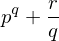

In [8]:
p,q,r = symbols("p,q,r")
p**q + r/q

Además de la forma anterior, también es posible tener variables simbólicas disponibles si se importan 
del módulo `abc` de SymPy:

In [9]:
from sympy.abc import a,b,c,d

In [10]:
(a + b)*(c + d)

## Manipulación algebraica

SymPy es una poderosa herramienta de manipulación y simplificación algebraica, en lo subsiguiente se revisarán 
algunos casos elementales y se describirá el uso de las herramientas (funciones) que proporciona.

En primera instancia se definen algunas variables simbólicas a utilizar:

In [151]:
x,y,z = symbols("x,y,z")
a,b,c,d,k,m,n = symbols("a,b,c,d,k,m,n")

Para las expresiones algebraicas formadas en SymPy por default se *evalúan* y simplifican los términos semejantes. 
Vea los siguientes casos:

In [12]:
x**2 + 5*x**3 - 10*x**2 + 5*x - 10*(x + 1)

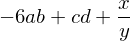

In [13]:
a*b + c*d + x/y - 7*a*b

Naturalmente para simplificaciones y operaciones un poco menos obvias, habrá que especificarle lo que se requiere.

Una de las operaciones elementales de simplificación en álgebra es la factorización, SymPy dispone de la 
función `factor`, la cual toma una expresión algebraica y la factoriza conforme sea posible. 
Por ejemplo, suponiendo que se tiene la expresión $ab + ac$, es sencillo identificar que se puede  
factorizar como $a(b+c)$, SymPy hace lo mismo sin sobresalto alguno.

In [14]:
factor(a*b + a*c)

De igual forma se sabe que una expresión de la forma $ ac + ad + bc + bd $ se puede factorizar como 
$ (a + b) (d + c) $.

In [15]:
factor( a*c + a*d + b*c + b*d )

Así, para un binomio al cuadrado se sabe que, $ (a+b)(a+b) $ es la factorización de una expresión del tipo
$ a^2 + 2ab + b^2 $.


In [16]:
factor(a**2 + 2*a*b + b**2)

¿Se puede hacer el proceso *inverso*, es decir, dados dos factores obtener su expresión *expandida*? 
Por supuesto, para ello se hace uso de la función `expand`. 


In [17]:
expand( (x-7)*(x-3) )

SymPy puede manejar cualquier cantidad de factores y devolver la expresión que resulta de realizar la multiplicación 
algebraica, sin estar limitada siquiera por la cantidad de variables simbólicas.

In [18]:
expand( (x + y)*(x - y) )

In [19]:
expand( (x + y)*(x+y) )

In [20]:
expand( (x + y)**2 )

In [21]:
expand( (x + y)**3 )

In [22]:
expand( a*(m + n)**2 )

De manera general, si requiere simplificar una expresión algebraica SymPy dispone de una función más o menos universal que funcionará en la mayoría de los casos: `simplify`. Por ejemplo, suponiendo que 
se tiene la siguiente expresión algebraica racional y se requiere reducir lo más posible:

$$ \frac{x^2 - 3x}{x^2 + 3x}$$

Se puede notar que tanto en el numerador como en el denominador se puede factorizar $x$, lo cual conduce a:

$$ \frac{x(x - 3)}{x(x + 3)} = \frac{x-3}{x+3} $$

Con SymPy:

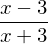

In [25]:
simplify( (x**2 - 3*x)/(x**2 + 3*x) )

Lo mismo para una expresión que involucre funciones trigonométricas, por ejemplo, cualquiera que haya cursado matemáticas 
del nivel secundario, al menos, sabe que $\sin^2 x + \cos^2 x = 1 $, y también *lo sabe* SymPy:

In [26]:
simplify( sin(x)**2 + cos(x)**2 )

Pero también *sabe* que $ \cos x \cos y - \sin x \sin y = \cos(x+y) $.

In [23]:
simplify( cos(x)*cos(y) - sin(x)*sin(y) )

O bien:

In [25]:
simplify( (1+tan(x)**2)/(1+cot(x)**2) )

Habitualmente para la manipulación de expresiones que contienen funciones trigonométricas se suele utilizar 
la función `trigsimp` que en muchos casos lo que devuelva coincidirá con `simplify`. 
Sin embargo, si en lugar de reducir una expresión trigonométrica se requiere expandirla, como 
en el caso del coseno o seno de la suma de dos ángulos, probablemente por intuición se utilizaría `expand`, 
pero aquí no funciona como puede verificar.

In [26]:
expand( sin(x + y) )

En este caso puede utilizar la función `expand_trig`, la cual maneja de mejor manera las manipulaciones trigonométricas:

In [28]:
expand_trig( sin(x+y) )

## Resolviendo ecuaciones e inecuaciones

SymPy dispone de la función `solve`, la cual resuelve desde ecuaciones polinomiales, sistemas de ecuaciones lineales, 
inecuaciones, hasta sistemas de ecuaciones no lineales. La sintaxis de `solve` es polimórfica y en general depende 
de lo que se requiera resolver, tendiendo siempre a que sea posible especificar el mínimo número de parámetros.

En las siguientes subsecciones se describen algunos casos, se asumirá en lo subsiguiente que además de importar SymPy 
se definieron las siguientes variables simbólicas:

In [294]:
x,y,z = symbols("x,y,z")
a,b,c = symbols("a,b,c")

### Ecuaciones polinómicas

La sintaxis más elemental de `solve` es pasando un sólo argumento, el cual se espera sea una expresión algebraica 
y se considera que esta estará igualada a cero. Por ejemplo para resolver la ecuación lineal $ x - 3 = 0 $:

In [298]:
solve( x - 3 )

Para una ecuación cuadrática $ x^2 + 2x + 2 = 0 $: 

In [300]:
solve(x**2 + 2*x + 2)

En este caso la ecuación tiene soluciones complejas, la unidad imaginaria en SymPy se especifica mediante 
el símbolo `I`.

Si se quisiera resolver la ecuación cuadrática en su forma general, por intuición y lo que sabemos hasta ahora, haríamos:

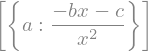

In [302]:
solve(a*x**2 + b*x + c)

Note que el problema está en que al haber más de una variable simbólica, SymPy no sabe con respecto a qué variable debe 
resolver y toma la primera en orden alfabético. Para especificar explícitamente respecto a qué variable resolver, 
se puede indicar mediante un segundo argumento:

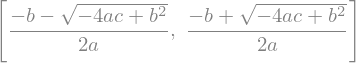

In [304]:
solve(a*x**2 + b*x + c, x)

Puede verificar que devuelve, en efecto, la tan conocida fórmula general.

### Ecuaciones trigonométricas

Para resolver ecuaciones trigonométricas podemos utilizar también la función `solve`. Por ejemplo, vamos a resolver la ecuación:

$$ \sin x = 0 $$

Para esto definimos la ecuación trigonométrica utilizando `Eq`:

In [319]:
eq = Eq(sin(x), 0)
eq

Y resolvemos con `solve`:

In [326]:
sol = solve(eq, x)
sol

Observa que nos devuelve dos soluciones, sin embargo, en este punto seguramente recordarás que la función $\sin x$ *corta* múltiples veces al eje de las abscisas. Esto implica, evidentemente, que la ecuación $\sin x = 0$ tiene multitud de soluciones y que lo que nos devuelve `solve` son únicamente dos de ellas.

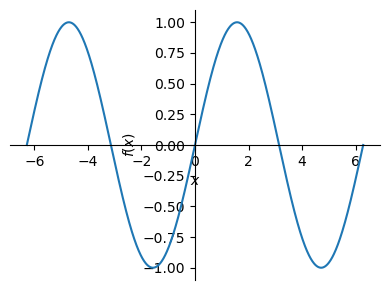

In [308]:
plot(eq.lhs, (x,-2*pi,2*pi), size=(4,3))

## Álgebra lineal

### Vectores

Un vector denota una cantidad física que tiene magnitud y orientación en un determinado sistema de referencia. 
En SymPy, los vectores se pueden definir mediante la clase `Matrix` del módulo `matrices`. Para crear un vector, a la clase `Matrix` le pasamos como argumento una lista. 

Por ejemplo, vamos a definir dos vectores $\vec{u}$ y $\vec{v}$, dados por:

$$ \vec{u} = \begin{bmatrix} 2 \\ 1 \\ -5 \end{bmatrix} \qquad ; \qquad 
\vec{v} = \begin{bmatrix} 4 \\ -1 \\ 3 \end{bmatrix}
$$


In [16]:
u = Matrix([2,1,-5])
v = Matrix([4,-1,3])

Una suma y resta vectorial se pueden ejecutar sin muchas complicaciones, mediante los operadores 
aritméticos ya conocidos.

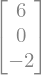

In [17]:
u + v

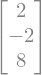

In [18]:
v - u

La magnitud de un vector la podemos calcular utilizando el método `norm`.

In [31]:
u.norm()

In [32]:
v.norm()

Recuerde que si requiere ver las expresiones resultantes en la notación decimal debe usar `evalf`. 

El producto escalar de dos vectores puede calcularlo utilizando el método `dot`, por 
ejemplo $ \vec{u} \cdot \vec{v} $ lo puede especificar como:

In [21]:
u.dot(v)

Para calcular el producto vectorial utilice el método `cross`, por ejemplo 
$ \vec{u} \times \vec{v} $:

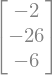

In [22]:
u.cross(v)

Recuerde que el producto vectorial no es conmutativo, por tanto, $\vec{v} \times \vec{u} $ resultará en un vector 
diferente al obtenido anteriormente, como puede verificar enseguida:

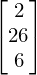

In [53]:
v.cross(u)

Obviamente, los vectores en SymPy también pueden contener expresiones simbólicas, veamos el siguiente ejemplo:

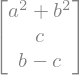

In [41]:
a,b,c = symbols("a,b,c")
w = Matrix([a**2 + b**2, c, b - c])
w

Y podemos trabajar este vector con las operaciones revisadas previamente:

In [43]:
w.dot(u)

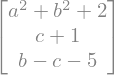

In [44]:
w + u

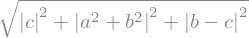

In [45]:
w.norm()

### Matrices

Las matrices son arreglos rectangulares de números o cantidades simbólicas. En SymPy, se definen utilizando la clase `Matrix`, pasándole como argumentos una lista de listas, donde cada sublista corresponde a una fila de la matriz.

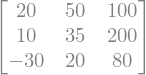

In [108]:
Matrix([[20,50,100], [10,35,200], [-30,20,80]])

Podemos también crear otras matrices particulares con algunas funciones. Por ejemplo, la función `zeros` nos permite crear una matriz compuesta de ceros:

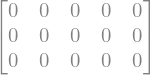

In [78]:
zeros(3,5)

El primer argumento indica la cantidad de filas y el segundo la cantidad de columnas. Si pasamos un único argumento, entonces nos devolverá una matriz cuadrada:

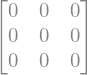

In [79]:
zeros(3)

La función `ones` nos permite crear matrices de unos, con una sintaxis similar a `zeros`:

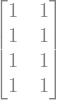

In [80]:
ones(4,2)

La función `eye` nos permite crear una matriz identidad, recibiendo como argumento el tamaño de la matriz:

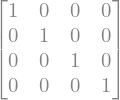

In [82]:
eye(4)

La función `diag` permite crear una matriz diagonal:

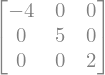

In [84]:
diag(-4,5,2)

La clase `Matrix` también nos permite definir matrices utilizando una función `lambda` que genere sus elementos.

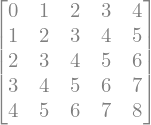

In [105]:
Matrix(5,5, lambda i,j: i+j)

Observa que en este caso cada elemento de la matriz es la suma del índice `i` de su fila y el índice `j` de su columna.

### Operaciones básicas con matrices

Vamos a definir las matrices $A$, $B$ y $C$, dadas por:

$$ A = \begin{bmatrix}
20 & 50 & 100 \\
10 & 35 & 200 \\
-30 & 20 & 80 
\end{bmatrix}
\qquad
B = \begin{bmatrix}
12 & 26 & 45 \\
3 & -15 & 18 \\
54 & 20 & 0 
\end{bmatrix}
\qquad
C = \begin{bmatrix}
5 & 9 \\
2 & 3 \\
-10 & 8
\end{bmatrix}
 $$

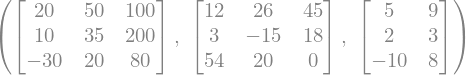

In [107]:
A = Matrix([[20,50,100], [10,35,200], [-30,20,80]])
B = Matrix([[12,26,45],[3,-15,18],[54,20,0]])
C = Matrix([[5,9], [2,3], [-10,8]])
A, B, C

Para realizar una suma de matrices utilizamos el operador `+`:

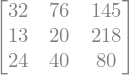

In [109]:
A + B

Naturalmente, y como es esperable, SymPy *conoce* y aplica las reglas de álgebra de matrices, observe:

In [110]:
A + C

ShapeError: Matrix size mismatch: (3, 3) + (3, 2)

SymPy es muy explícito en ese tipo de situaciones y nos imprime un mensaje de error suficientemente descriptivo. Recuerde que no podemos sumar dos matrices de distinto tamaño. 

Para efectuar una multiplicación utilizamos el operador `*`:

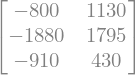

In [112]:
A * C

Es importante considerar que para que dos matrices se pueden multiplicar, la primera debe tener tantas columnas como filas tenga la segunda, es decir, si tenemos una matriz $A$ de tamaño $m \times n$ y una matriz $B$ de tamaño $ p \times q $, entonces para poder efectuar el producto $AB$ entonces $ n = p $ y la matriz resultante tendrá un tamaño $ m \times q $. 

De las matrices definidas con anterioridad, es sencillo ver que el producto de $AC$ se puede efectuar puesto que $A$ tiene 3 columnas, la misma cantidad de filas que posee $C$, y resulta una matriz de $3 \times 2$. Sin embargo, no es posible efectuar el producto $CA$, dado que $C$ tiene $2$ columnas y $A$ tiene 3 filas, tal y como se puede verificar enseguida:

In [113]:
C*A

ShapeError: Matrix size mismatch: (3, 2) * (3, 3).

### Determinante, inversa y transpuesta

El **determinante** de una matriz podemos calcularlo mediante la función `det`:

In [127]:
det(B)

O bien, mediante el propio método `det`:

In [128]:
B.det()

La **matriz inversa** podemos calcularla utilizando el método `inv`:

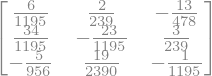

In [116]:
A.inv()

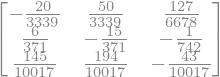

In [117]:
B.inv()

Recuerda que la matriz inversa está definida únicamente para matrices cuadradas. Si intentamos calcular el determinante de una matriz que no cumple esta condición entonces Python/SymPy lanzará un `NonSquareMatrixError`.

In [132]:
C.inv()

NonSquareMatrixError: A Matrix must be square to invert.

La **transpuesta** de una matriz se puede obtener accediendo al atributo `T`

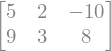

In [58]:
C.T

### Sistemas de ecuaciones lineales

Un **sistema de ecuaciones lineales** es un conjunto finito de ecuaciones lineales, cada una con las mismas variables. Una solución de un sistema de ecuaciones lineales es un vector que simultáneamente es una solución de cada ecuación en el sistema. El **conjunto solución** de un sistema de ecuaciones lineales es el conjunto de todas las soluciones del sistema. [^poole]

De manera general, un sistema de $m$ ecuaciones lineales con $n$ incógnitas se puede escribir de la siguiente manera:

$$
\begin{matrix}
a_{11} x_1 + a_{12} x_2 + \cdots + a_{1n} x_n = b_1 \\
a_{21} x_1 + a_{22} x_2 + \cdots + a_{2n} x_n = b_2 \\
\vdots \\
a_{m1} x_1 + a_{m2} x_2 + \cdots + a_{mn} x_n = b_m \\
\end{matrix}
$$

Este sistema se puede escribir en la forma de una ecuación matricial:

$$
\begin{bmatrix}
a_{11} & a_{12} & \cdots & a_{1n} \\
a_{21} & a_{22} & \cdots & a_{2n} \\
\vdots & \vdots & \ddots & \vdots \\
a_{m1} & a_{m2} & \cdots & a_{mn} 
\end{bmatrix}
\begin{bmatrix}
x_1 \\ x_2 \\ \vdots \\ x_n \\
\end{bmatrix} = 
\begin{bmatrix}
b_1 \\ b_2 \\ \vdots \\ b_m
\end{bmatrix}
$$

$$ 
A \mathbf{x} = \mathbf{b}
$$

La matriz $A$ se denomina la matriz de coeficientes del sistema, el vector $\mathbf{x}$ contiene a los valores desconocidos y el vector $\mathbf{b}$ se denomina el vector de términos independientes.


En SymPy podemos resolver un sistema de ecuaciones lineales de varias maneras, por ejemplo, una primera aproximación puede ser utilizar la función `solve` que veíamos en secciones previas. En este caso la sintaxis más simple para `solve` sería:

```python
solve([eq1, eq2, ..., eqn])
```

Donde `[eq1, eq2, ..., eqn]` es una lista que contiene las expresiones simbólicas de las ecuaciones lineales a resolver. 

Para ejemplificar vamos a resolver el siguiente sistema de dos ecuaciones lineales con dos incógnitas:

$$ 
\begin{matrix}
x_1 + x_2 = 0 \\
x_1 - x_2 = 2
\end{matrix}
$$ 

In [6]:
x1,x2 = symbols("x_1, x_2")
eq1 = x1 + x2
eq2 = x1 - x2 - 2
solve([eq1, eq2])

Observa que en las variables `eq1` y `eq2` estamos definiendo las ecuaciones lineales reescritas de tal manera que del lado derecho tengamos un cero (recuerda que SymPy asume que una ecuación que pasamos a la función `solve` está igualada a cero), es decir, el término independiente *lo pasamos* del lado izquierdo:

$$ 
\begin{matrix}
x_1 + x_2 = 0 \\
x_1 - x_2 - 2 = 0
\end{matrix}
$$ 

Sin embargo, también podemos utilizar `Eq` para definir ambos miembros de una ecuación, veamos como lo haríamos:

In [52]:
x1,x2 = symbols("x_1, x_2")
eq1 = Eq(x1 + x2, 0)
eq2 = Eq(x1 - x2, 2)
solve([eq1, eq2], (x1,x2))

Naturalmente, ambas maneras son equivalentes. La función `solve` nos devuelve un diccionario con las incógnitas como claves y como valor la solución correspondiente.

Podemos utilizar también la función `linsolve`, la cual está pensada especificamente para resolver sistemas de ecuaciones lineales. La sintaxis básica de `linsolve` es:

```python
linsolve(sistema, variables)
```

Donde `sistema` es una lista de las ecuaciones a resolver y `variables` una lista (o tupla) de las variables o valores desconocidos. Para ejemplificar vamos a resolver el siguiente sistema de ecuaciones:

$$ 
\begin{matrix}
2x_1 + 4 x_2 + 6 x_3 = 18 \\
4 x_1 + 5 x_2 + 6 x_3 = 24 \\
3 x_1 + x_2 - 2 x_3 = 4
\end{matrix}
$$ 

In [48]:
x1,x2,x3 = symbols("x_1, x_2, x_3")
eq1 = 2*x1 + 4*x2 + 6*x3 - 18
eq2 = 4*x1 + 5*x2 + 6*x3 - 24
eq3 = 3*x1 + x2 - 2*x3 - 4
linsolve([eq1, eq2, eq3], (x1,x2,x3))

A la función `linsolve` se le puede pasar también el sistema en la forma de una tupla que contiene la matriz de coeficientes $A$ y el vector de términos independientes $\mathbf{b}$, para el sistema de ecuaciones anterior se tendría que:

$$
A = \begin{bmatrix}
2 & 4 & 6 \\ 4 & 5 & 6 \\ 3 & 1 & -2 \\
\end{bmatrix} \qquad
\mathbf{b} = \begin{bmatrix} 18 \\ 24 \\ 4 \end{bmatrix}
$$

Entonces:

In [76]:
A = Matrix([[2,4,6], [4,5,6], [3,1,-2]])
b = Matrix([18,24,4])
linsolve((A,b), (x1,x2,x3))

También es posible utilizar la [matriz aumentada ](https://es.wikipedia.org/wiki/Matriz_aumentada) del sistema de ecuaciones como argumento de la función `linsolve`, por ejemplo:

In [78]:
A_ = Matrix([[2,4,6,18], [4,5,6,24], [3,1,-2,4]]) # matriz aumentada
linsolve(A_, (x1,x2,x3))

### Eigenvalores y eigenvectores

Los eigenvalores y eigenvectores son características de una matriz en el sentido de que contienen información importante acerca de la naturaleza de la matriz. [^poole]

Sea $A$ una matriz de $n \times n$. Un escalar $\lambda$ se llama eigenvalor de $A$ si existe un vector $\vec{x}$ distinto de cero tal que $ A \vec{x}  = \lambda \vec{x} $. Tal vector $\vec{x}$ se llama eigenvector de $A$ correspondiente a $\lambda$.

[^poole]: Poole, D. (2017). Algebra lineal, una introducción moderna (Cuarta edición). Cengage Learning.

Para encontrar los eigenvalores de una matriz $A$, resolvemos la ecuación característica:

$$ \det(A - \lambda I) = 0 $$

donde $I$ es la matriz identidad de la misma dimensión que $A$. Resolver este sistema da un polinomio en $\lambda$, cuyas raíces son los eigenvalores.

Para cada eigenvalor $\lambda$, los eigenvectores se encuentran resolviendo el sistema de ecuaciones lineales:

$$ \left( A - \lambda I \right) \vec{v} = 0 $$

En SymPy podemos calcular los eigenvalores de una matriz utilizando el método `eigenvals`:

In [127]:
A = Matrix([[2,1], [1,2]])
A.eigenvals()

Observa que en este caso el método nos devuelve un diccionario con los dos eigenvalores como claves y su multiplicidad como valor. 

Los eigenvectores de $A$ podemos determinarlos utilizando el método `eigenvects`:

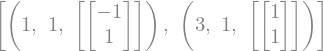

In [131]:
A.eigenvects()

El método `eigenvects` nos devuelve una lista de tuplas. Cada tupla contiene el eigenvalor, su multiplicidad y una lista de eigenvectores asociados a ese eigenvalor.

## Cálculo diferencial e integral

### Límites

Para calcular límites matemáticos SymPy dispone de la función `limit`, la cual requiere al menos tres 
argumentos de entrada: la función, variable y valor al que tiende. Por ejemplo, si se quiere calcular 
el siguiente límite:

$$ \lim_{x \to 0} \frac{\sin x}{x} $$

Tendríamos que hacer lo siguiente:

In [144]:
x = symbols("x")
limit(sin(x)/x, x, 0)

Para calcular limites laterales debe pasarse un cuarto argumento, por ejemplo:

In [147]:
limit(1/(x-5), x, 5, "-")

In [149]:
limit(1/(x-5), x, 5, "+")

El símbolo `+` denota el cálculo de un límite lateral por la derecha y el símbolo `-` un límite lateral por la izquierda.

Para calcular límites cuando la variable tiende a infinito podemos utilizar `oo` para especificarlo. Por ejemplo, vamos a calcular el siguiente límite:

$$ 
\lim_{x \to \infty} \frac{x^2 - 1}{x^2 + 1}
$$

In [158]:
limit((x**2-1)/(x**2+1), x, oo) 

### Derivadas

Las derivadas en Python se calculan utilizando la función `diff`, misma que en su forma más simple espera 
al menos dos argumentos: una expresión algebraica y una variable respecto a la cual derivar. Por ejemplo:


In [36]:
diff(exp(x)*cos(x), x)

Es posible también especificar una derivada de orden superior mediante un tercer argumento:

In [37]:
diff(5*x**2 + 3*x - 10, x, 2)

La instrucción anterior calcula la segunda derivada de la función $ f(x) = 5x^2 + 3x - 10 $. 

#### Derivación implícita

Existen funciones en las que no pueden expresarse explícitamente una variable en términos de la otra, y en su lugar se define una relación implícita entre las variables. Por ejemplo, la siguiente es una función definida implícitamente:

$$ 
x^2 + y^2 = 25
$$

Para derivarla utilizamos el método de derivación implícita, el cual consiste en:

1. Derivar ambos lados de la ecuación con respecto a $x$, considerando que $y=y(x)$.
2. Resolver la ecuación que resulta para $dy/dx$

Podemos implementar esto en SymPy de la siguiente manera:

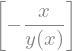

In [242]:
x = symbols("x")
y = Function("y")(x) # Definimos a y(x)

eq = x**2 + y**2 - 25 # Creamos la ecuación implícita
d_eq = diff(eq, x) # Derivamos con respecto a x
dy_dx = diff(y,x) # Derivada de y(x) con respecto a x -> dy/dx

solve(d_eq, dy_dx) # Despejamos dy/dx de la derivada

#### Máximos y mínimos de una función

Supongamos que en $x=x_1$ la derivada de la función $y=f(x)$ se reduce a cero, es decir, $f'(x)=0$. Admitamos, además que existe la segunda derivada, $f''(x)$, y es continua sobre cierta vecindad del punto $x_1$. Para este caso es válido el siguiente teorema:

> **Teorema 1.** Si $f'(x_1)=0$, entonces en $x=x_1$ la función tiene máximo cuando $f''(x_1)<0$, y, un mínimo cuando $f''(x_1)>0$.

De acuerdo al teorema anterior, para caracterizar los puntos críticos de una función $f(x)$ es necesario utilizar el criterio de la segunda derivada. Entendiendo que los puntos críticos se obtienen de resolver la ecuación $f'(x)=0$.

En SymPy, utilizando la función `diff` podemos calcular las derivadas y luego con `solve` resolver la ecuación $f'(x)=0$ para encontrar los puntos críticos. Para ejemplificar vamos a calcular y caracterizar los puntos críticos de la función $f(x) = x^3 - x$, comenzamos primero definiendo dicha función:

In [255]:
x = symbols("x")
fx = x**3 - x
fx

Ahora vamos a calcular tanto la primera como la segunda derivada:

In [257]:
df = diff(fx, x) # 1era. derivada
d2f = diff(fx, x, 2) # 2da. derivada
df, d2f

Los puntos críticos los calculamos resolviendo la ecuación $f'(x)=0$

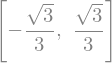

In [259]:
pc = solve(Eq(df, 0))
pc

Para determinar si se trata de un mínimo o máximo, utilizamos el criterio de la segunda derivada, sustituyendo los puntos críticos en $f''(x)$, es decir:

In [261]:
d2f.subs(x,pc[0]) # Primer punto crítico

In [262]:
d2f.subs(x,pc[1]) # Segundo punto crítico

Con esto determinamos, de acuerdo con el teorema 1, que el primer punto crítico $\left(\frac{-\sqrt{3}}{3}\right)$ es un máximo y el segundo $\left(\frac{\sqrt{3}}{3}\right)$ un mínimo. Podemos comprobarlo trazando la gráfica correspondiente:

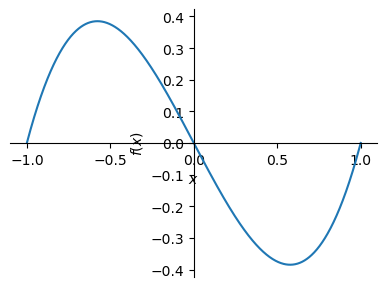

In [265]:
plot(fx, (x, -1, 1), size=(4,3))

Los valores máximos y mínimos de $f(x)$ podemos obtenerlos sustituyendo $x=p_{c_1}$ y $x=p_{c_2}$, lo cual podemos hacer mediante el método `subs`:

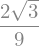

In [267]:
fx.subs(x,pc[0]) # valor máximo

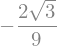

In [268]:
fx.subs(x,pc[1]) # valor mínimo

Este proceso lo podríamos *automatizar* un poco con una función como la siguiente:

In [271]:
def max_min_fun(f):
    """
    Calcula los máximos y mínimos de una función f(x)
    """
    df = diff(f, x) # 1era. derivada
    d2f = diff(f, x, 2) # 2da. derivada
    pcs = solve(Eq(df,0)) # puntos críticos
    maxmin = {}
    for k,pc in enumerate(pcs):
        if d2f.subs(x,pc)>0: 
            maxmin.update({f"PC{k+1} (Mín.)": (pc, f.subs(x,pc))})
        elif d2f.subs(x,pc)<0: 
            maxmin.update({f"PC{k+1} (Máx.)": (pc, f.subs(x,pc))})
        else: 
            maxmin.update({f"PC{k+1} (Indefinido)": (pc, f.subs(x,pc))})
    return maxmin

Probemos con el ejemplo trabajado previamente:

In [274]:
max_min_fun(fx)

{'PC1 (Máx.)': (-sqrt(3)/3, 2*sqrt(3)/9),
 'PC2 (Mín.)': (sqrt(3)/3, -2*sqrt(3)/9)}

Vemos que la función devuelve un diccionario con los puntos críticos de la función, indicando además si se trata de un máximo o mínimo.

### Integrales

Para calcular integrales vamos a utilizar la función `integrate`, la cual acepta al menos dos argumentos: la función a integrar y la variable con respecto a la cual se integra, por ejemplo:


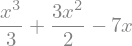

In [13]:
x = symbols("x")
integrate(x**2 + 3*x - 7, x)

Esta instrucción calcula la integral:

$$ \int \left( x^2 + 3x - 7 \, \right) \,\, dx = \frac{x^3}{3} + \frac{3x^2}{2} - 7x + C $$

Note que la expresión algebraica devuelta por Python no contiene la constante de integración, por default SymPy no la considera. Sí en algún caso específico necesita a la constante de integración puede adicionarla manualmente.

Las integrales definidas se pueden calcular si el segundo argumento se hace una tupla de la forma `(variable, a, b)`, donde `a` y `b` indican el límite inferior y superior a evaluar en la integral. Por ejemplo, para calcular:

$$ \int_0^{\pi} \sin x \, dx $$

In [16]:
integrate(sin(x), (x, 0, pi))

O para:

$$ \int_{-5}^{5} z^2 \, dz $$

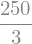

In [21]:
z = symbols("z")
integrate(z**2, (z,-5,5))

## Ecuaciones diferenciales

Una ecuación diferencial es cualquier ecuación que contiene las derivadas de una o más variables dependientes con respecto a una o más variables independientes [^zill]. Las ecuaciones diferenciales son fundamentales en ingeniería, para modelar una amplia variedad de fenómenos físicos.

[^zill]: Zill, G.D., Wright, W.S. & Cullen, M.R. (2012). Matemáticas avanzadas para ingeniería. McGraw-Hill.

Si una ecuación diferencial contiene únicamente derivadas ordinarias de una o más variables dependientes con respecto a una sola variable independiente, se dice que es una ecuación diferencial ordinaria (EDO). A continuación se muestran ejemplos de EDO:

$$ 
\frac{dy}{dx} + 5y = e^x
$$

$$ 
\frac{d^2y}{dx^2} -  \frac{dy}{dx} + 6y = 0
$$

Una ecuación en la que se presentan las derivadas parciales de una o más variables dependientes de dos o más variables independientes se denomina ecuación diferencial parcial (EDP), por ejemplo:

$$
\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} = 0
$$
$$
\frac{\partial^2 u}{\partial x^2} = \frac{\partial^2 u}{\partial t^2} - 2 \frac{\partial u}{\partial t}
$$

### ¿Cómo formar la expresión de una EDO?

Una ecuación diferencial ordinaria en el caso más general tendrá términos que dependen de la función, sus derivadas, la variable independiente y constantes. Por ejemplo, observa la siguiente EDO de primer orden:

$$ 
\frac{dy}{dx} = y + \sin x
$$

El término $ \sin x $ depende de la variable independiente $x$, $y$ es la función $y(x)$ y $dy/dx$ su derivada de primer orden. En SymPy, para definir la variable independiente utilizamos `symbols`, sin embargo, para crear $y(x)$ debemos utilizar `Function` para indicar que estamos creando una función que depende de una variable, así pues:

In [7]:
x = symbols("x")
y = Function("y")(x)

Para definir la derivada de primer orden de $y$ podemos utilizar el método `diff`:

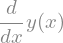

In [10]:
y.diff()

Para escribir la ecuación diferencial completa utilizamos la clase `Eq`:

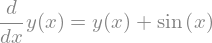

In [13]:
edo = Eq(y.diff(), y + sin(x))
edo

Las derivadas de orden superior se pueden definir utilizando también `diff`, pero agregando el argumento correspondiente al orden de la derivada, por ejemplo, para la derivada de segundo orden:

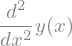

In [15]:
y.diff(x,2)

Vamos a suponer que queremos definir la siguiente ecuación diferencial de segundo orden:

$$  
\frac{d^2x}{dt^2} + 64 x = 0
$$

No pierdas de vista que en este caso $t$ es la variable independiente y $x(t)$ la función. Tendríamos entonces:

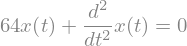

In [18]:
t = symbols("t")
x = Function("x")(t)
edo = Eq(x.diff(t,2) + 64*x, 0)
edo

La función $x$ se puede crear sin indicar explícitamente la variable de la cual depende, por ejemplo:

In [30]:
t = symbols("t")
x = Function("x")

Para poder utilizar la función $x(t)$ tendríamos que pasarle como *argumento* la variable independiente, es decir:

In [46]:
x(t)

De tal manera que la EDO de segundo orden anterior podríamos definirla como sigue:

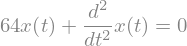

In [49]:
edo = Eq(x(t).diff(t,2) + 64*x(t), 0)
edo

### La función `dsolve`

Utilizando SymPy podemos resolver varios tipos de ecuaciones diferenciales. Para la mayoría de estos casos trabajaremos con la función [`dsolve`](https://docs.sympy.org/latest/modules/solvers/ode.html#sympy.solvers.ode.dsolve), la cual se utiliza para resolver cualquier tipo (soportado) de EDO. La sintaxis más básica es:

`dsolve(eq, f)`

* Siendo `eq` una expresión de la clase [Equality](https://docs.sympy.org/latest/modules/core.html#sympy.core.relational.Equality), o bien, una expresión que se asume está igualada a cero. En ambos casos, se considera que este argumento contiene la descripción de la EDO.

* `f` es la función con respecto a la cual se resuelve la ecuación diferencial; y en general, es un objeto de la clase [Function](https://docs.sympy.org/latest/modules/core.html#sympy.core.function.Function)

Para resolver problemas de valor inicial (PVI) podemos agregar el argumento `ics` a la función:

```python
dsolve(eq, f, ics=ICS)
```

Siendo `ICS`un diccionario que contiene las condiciones iniciales en la forma:

```python
{f(x0): x1, f(x).diff(x).subs(x, x2):x3, ...}
```

### EDO de primer orden

Una ecuación diferencial ordinaria de primer orden tiene la siguiente forma general:

$$  
\frac{dy}{dx} = f(x,y)
$$

Podemos utilizar `dsolve` para resolver EDO de este tipo. Por ejemplo, vamos a encontrar la solución para la siguiente EDO de primer orden:

$$
\frac{dy}{dx} - \frac{4}{x} y = x^5 e^x
$$

La variable independiente es $x$ y la función es $y$, entonces:

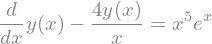

In [69]:
x = symbols("x")
y = Function("y")(x)
edo = Eq(y.diff() - (4/x)*y, x**5 * exp(x))
edo

In [71]:
dsolve(edo, y)

Veamos un ejemplo más, vamos a calcular una solución para:

$$
\frac{dQ}{dt} = k\left( Q - 70 \right)
$$

Donde $k$ es una constante, $Q$ es la función que depende de la variable independiente $t$, entonces:

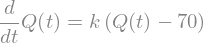

In [75]:
t = symbols("t")
k = symbols("k")
Q = Function("Q")(t)
edo = Eq(Q.diff(), k*(Q - 70))
edo

In [77]:
dsolve(edo, Q)

Revisemos ahora cómo resolver **problemas de valor inicial**. Supongamos que queremos calcular la solución para:

$$
\frac{dy}{dx} + y = x, \qquad y(0) = 4
$$

Entonces:

In [113]:
x = symbols("x") # variable independiente
y = Function("y")(x) # función y(x)
ICS = {y.subs(x,0): 4} # condicion inicial y(0)=4
edo = Eq(y.diff() + y, x) # creamos la expresión de la EDO
dsolve(edo, y, ics=ICS) 

Lo anterior también puede escribirse de la siguiente manera:

In [115]:
x = symbols("x") # variable independiente
y = Function("y") # función y, no indicamos explícitamente que depende de x.
ICS = {y(0): 4} # Podemos usar y(0) en lugar de y.subs(x,0)
edo = Eq(y(x).diff() + y(x), x) # Es necesario escribir y(x)
dsolve(edo, y(x), ics=ICS)

Observa que la diferencia está en cómo definimos la función $y$. En el segundo caso no definimos explícitamente, al momento de crear `y`, la variable de la cual depende, lo cual implica que para sustituir $x=0$ en la condición inicial se puede hacer con la sintaxis `y(0)`, sin embargo al momento de definir la EDO es necesario también indicar explícitamente que es una `y(x)`.

### EDO de segundo orden

Vamos a resolver la siguiente EDO de segundo orden:

$$
2 y'' - 5y' - 3y = 0
$$

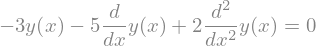

In [61]:
x = symbols("x") # variable independiente
y = Function("y")(x) # función y(x)
edo = Eq(2*y.diff(x,2) - 5*y.diff() - 3*y, 0)
edo

In [62]:
dsolve(edo, y)

Ahora veremos cómo resolver el siguiente problema de valor inicial de segundo orden:

$$
4y'' + 4y' + 17y = 0, \quad y(0)=-1, \quad y'(0)=2
$$

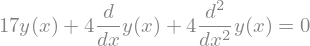

In [57]:
x = symbols("x")
y = Function("y")
ICS = {y(0): -1, 
       y(x).diff(x).subs(x,0): 2} # condiciones iniciales
edo = Eq(4*y(x).diff(x,2) + 4*y(x).diff() + 17*y(x), 0)
edo

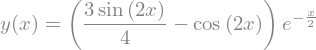

In [59]:
sol = dsolve(edo, y(x), ics=ICS)
sol

### Sistemas de EDO de primer orden

Un sistema de ecuaciones diferenciales ordinarias de primer orden consiste en un conjunto de ecuaciones donde las incógnitas son funciones de una variable independiente y cada ecuación involucra derivadas de primer orden de estas funciones. Un sistema con $n$ EDO de primer orden tiene la siguiente forma general:

$$\frac{dx_1}{dt} = f_1\left( t, x_1, x_2, \cdots, x_n \right) $$
$$\frac{dx_2}{dt} = f_2\left( t, x_1, x_2, \cdots, x_n \right)$$
$$\vdots\\ $$
$$\frac{dx_n}{dt} = f_n\left( t, x_1, x_2, \cdots, x_n \right)$$

Siendo $x_1$, $x_2$, $\cdots$, $x_n$ las funciones desconocidas.

En SymPy podemos utilizar la función `dsolve` para resolver un sistema de EDO de primer orden, con la siguiente sintaxis:

`dsolve([edo_1, edo_2, ..., edo_n])`

Siendo `edo_1`, `edo_2`, `edo_n` las $n$ EDO que conforman el sistema, pasadas en forma de una lista (o tupla). Para ejemplificar vamos a resolver el siguiente sistema de EDO de primer orden:

$$  
\frac{dx}{dt} = x + 3y
$$
$$
\frac{dy}{dt} = 5x + 3y 
$$

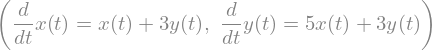

In [197]:
t = symbols("t") # variable independiente
x = Function("x")(t) # x(t)
y = Function("y")(t) # y(t)
edo_1 = Eq(x.diff(), x + 3*y) # 1era EDO de primer orden
edo_2 = Eq(y.diff(), 5*x + 3*y) # 2da EDO de primer orden
edo_1, edo_2

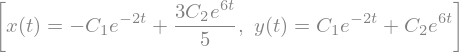

In [202]:
dsolve([edo_1, edo_2])

### Transformada de Laplace

La transformada de Laplace es una herramienta matemática utilizada para transformar una función de una variable (generalmente el tiempo 
$t$) en una función de una variable compleja $s$. Esta transformación es muy útil en ingeniería, ya que permite convertir ecuaciones diferenciales en ecuaciones algebraicas, lo que facilita su resolución.

Sea $f$ una función definida para $t \leq 0$. Entonces se dice que la integral:

$$ 
\mathscr{L}\left\{ f(t) \right\} = \int_0^{\infty} e^{-st} \, f(t) \, dt
$$

es la **transformada de Laplace** de $f$, siempre y cuando la integral converja. [^zill]

Por ejemplo, podemos calcular por definición la transformada de Laplace de la función $f(t)= t$, para esto en SymPy haríamos lo siguiente:

In [6]:
s = symbols("s", positive=True)
t = symbols("t")
f = t

integrate(exp(-s*t)*f, (t,0,oo))

O para la función $ f(t) = \cos(t) $:

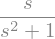

In [9]:
s = symbols("s", positive=True)
t = symbols("t")
f = cos(t)

integrate(exp(-s*t)*f, (t,0,oo))

SymPy nos proporciona también una función `laplace_transform` que nos permite calcular la transformada de Laplace de una función $f(t)$, cuya sintaxis es:

```python
laplace_transform(f, t, s)
```

Veamos cómo funciona con el mismo ejemplo anterior:

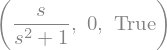

In [38]:
s = symbols("s", positive=True)
t = symbols("t", positive=True)
f = cos(t)

laplace_transform(f, t, s)

Si queremos que nos devuelva únicamente  la transformada entonces le podemos pasar el argumento `noconds=True`:

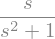

In [41]:
laplace_transform(f, t, s, noconds=True)

#### Transformadas de derivadas

La transformada de Laplace se puede utilizar para resolver ecuaciones diferenciales, para esto es necesario aplicar la transformada de Laplace a la función y sus derivadas, para expresarlas en el dominio de la variable $s$. Sea $y(t)$ una función que depende del tiempo, la transformada de Laplace de esta función la podemos expresar como:

$$
\mathscr{L}\left\{ y(t) \right\} = Y(s)
$$

La transformada de Laplace de la derivada de primer orden de esta función está dada por:

$$
\mathscr{L}\left\{ y'(t) \right\} = s Y(s) - y(0)
$$

Y la transformada de Laplace de la derivada de segundo orden de esta función está dada por:

$$
\mathscr{L}\left\{ y''(t) \right\} = s^2 Y(s) - s \, y(0) - y'(0)
$$


Ahora, vamos a utilizar SymPy para expresar la transformada de Laplace de una función $y(t)$:

In [61]:
t = symbols("t")
s = symbols("s")
y = Function("y")(t)
laplace_transform(y, t, s, noconds=True)

Observa que en este caso SymPy nos devuelve una expresión que deja indicada dicha transformada, sin embargo, podemos hacer de forma *manual* la sustitución, para esto vamos a definir una función `Y` que dependa de `s`, es decir:

In [66]:
Y = Function("Y")(s)
Y

Y luego, vamos a definir un diccionario que contenga la sustitución de la transformada por esta función:

In [88]:
ys_sust = {laplace_transform(y, t, s, noconds=True): Y}

De tal manera que si aplicamos nuevamente la transformada a $y(t)$ y hacemos la sustitución previa, entonces obtenemos $Y(s)$:

In [93]:
laplace_transform(y, t, s, noconds=True).subs(ys_sust)

Podemos ahora pasar a calcular la transformadad de Laplace de una derivada de primer orden:

In [96]:
laplace_transform(y.diff(), t, s, noconds=True) # Transformada de una derivada de primer orden

Observa que la transformada de la función $Y(s)$ se sigue expresando en la forma $\mathcal{L}_t\left[y(t)\right](s)$, no obstante podemos también hacer la sustitución que indicábamos antes:

In [102]:
laplace_transform(y.diff(), t, s, noconds=True).subs(ys_sust) 

De manera similar podemos hacer para la derivada de segundo orden:

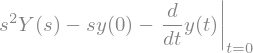

In [107]:
laplace_transform(y.diff(t,2), t, s, noconds=True).subs(ys_sust) # Transformada de una derivada de segundo orden

#### Resolviendo PVI

Resolviendo el siguiente PVI:

$$
\frac{dy}{dt} + 3y = 13 \sin(2t), \quad y(0) = 6
$$

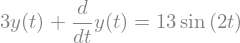

In [119]:
t = symbols("t", positive=True)
s = symbols("s", positive=True)
y = Function("y")(t) # y(t)
Y = Function("Y")(s) # Y(s)
ys_sust = {laplace_transform(y, t, s, noconds=True): Y } 
ics = {y.subs(t,0): 6} # condición inicial
edo = Eq(y.diff() + 3*y, 13*sin(2*t))
edo

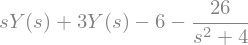

In [117]:
ec_transformada = laplace_transform(edo.lhs - edo.rhs, t, s, noconds=True).subs(ys_sust | ics)
ec_transformada

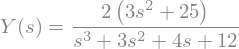

In [121]:
Ys_ec = Eq(Y, solve(ec_laplace, Y)[0])
Ys_ec

In [123]:
y_t = Eq(y, inverse_laplace_transform( Ys_ec.rhs, s, t) )
y_t

## Cálculo de varias variables

### Funciones multivariable

Por escribir

In [127]:
x,y = symbols("x,y")
fxy = x**2 + y**2
fxy

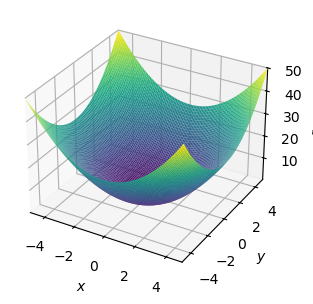

In [128]:
plotting.plot3d(fxy, (x,-5,5), (y,-5,5), size=(4,3))

In [133]:
fxy.subs({x:0.75, y:0.5})

### Derivadas parciales

### Vector gradiente

### Integrales múltiples

### Funciones vectoriales

Una función vectorial es una función cuyo dominio es conjunto de números reales y cuyo rango es un conjunto de vectores. 

In [60]:
t = symbols("t", positive=True)
a = symbols("a", positive=True)

In [62]:

integrate(r.diff().norm(), (t,0,2*pi))

#### Derivada de una función vectorial

La derivada $\mathbf{r}'$ de una función vectorial $\mathbf{r}$ se define casi de la misma manera que las funciones con valores reales:

$$ 
\frac{d\mathbf{r}}{dt} = \mathbf{r}'(t) = 
\lim_{h \to 0} \frac{\mathbf{r}(t+h) - \mathbf{r}(t)}{h}
$$

si este límite existe. De manera general, si $\mathbf{r}(t)$ es una función vectorial dada por:

$$ 
\mathbf{r}(t) = \begin{bmatrix} f(t) \\ g(t) \\ h(t) \end{bmatrix}
$$

donde $f(t)$, $ g(t) $ y $ h(t) $ son funciones derivables, entonces:

$$ 
\mathbf{r}'(t) = \begin{bmatrix} f'(t) \\ g'(t) \\ h'(t) \end{bmatrix}
$$

En SymPy podemos utilizar el método `diff` para derivar una función vectorial creada con la clase `Matrix`. Por ejemplo, vamos a suponer que queremos calcular la derivada para la siguiente función vectorial:

$$
\mathbf{r}(t) = \begin{bmatrix} \cos t \\ \sin t \\ t \end{bmatrix}
$$

Entonces, primero creamos la función vectorial:

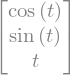

In [93]:
t = symbols("t")
r = Matrix([cos(t), sin(t), t])
r

Y la derivamos utilizando `diff`:

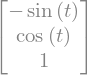

In [95]:
r.diff()

En el caso de que en la función vectorial aparezca más de una variable simbólica, entonces se debe indicar explícitamente que la derivada se realizará con respecto al parámetro $t$, de lo contrario Python nos lanzará un error, por ejemplo:

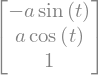

In [114]:
a = symbols("a")
r = Matrix([a*cos(t), a*sin(t), t])
r.diff(t)

Para calcular una derivada de orden superior de una función vectorial podemos encadenar los métodos `diff`:

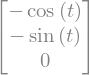

In [129]:
r = Matrix([cos(t), sin(t), t])
r.diff().diff()

O bien especificar mediante un segundo argumento el orden de la derivada:

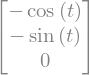

In [131]:
r.diff(t,2)

#### Integral de una función vectorial

La integral de una función vectorial continua $\mathbf{r}(t)$ se puede expresar en términos de las integrales de sus funciones componentes. Sea $\mathbf{r}(t)$ la función vectorial dada por:

$$ 
\mathbf{r}(t) = \begin{bmatrix} f(t) \\ g(t) \\ h(t) \end{bmatrix}
$$

Entonces:

$$
\int \mathbf{r}(t) \, dt = \begin{bmatrix} 
\int f(t) \,dt \\ \int g(t) \,dt \\ \int h(t) \,dt 
\end{bmatrix}
$$

De manera similar en el caso de una integral definida:

$$
\int_a^b \mathbf{r}(t) \, dt = \begin{bmatrix} 
\int_a^b f(t) \,dt \\ \int_a^b g(t) \,dt \\ \int_a^b h(t) \,dt 
\end{bmatrix}
$$

En SymPy podemos integrar una función vectorial utilizando el método `integrate` de la clase `Matrix`. Para ejemplificar vamos a calcular la integral de la siguiente función vectorial:

$$
\mathbf{r}(t) = \begin{bmatrix} \cos t \\ \sin t \\ t \end{bmatrix}
$$

Primero definimos la función:

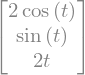

In [152]:
t = symbols("t")
r = Matrix([2*cos(t), sin(t), 2*t])
r

Integramos utilizando el método `integrate`:

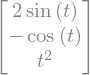

In [156]:
r.integrate()

Para evaluar la integral definida 

$$
\int_0^{\pi/2} \mathbf{r}(t)
$$

Tendríamos que pasarle al método `integrate` una tupla con la variable y los límites de integración:

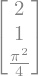

In [162]:
r.integrate((t,0,pi/2))

#### Longitud de arco

#### Curvatura de una función vectorial

La curvatura de la curva dada por una función vectorial $\mathbf{r}$ está dada por:

$$ 
\mathbf{\kappa}(t) = \frac{ \left| \mathbf{r}'(t) \times \mathbf{r}''(t) \right| }{ \left| \mathbf{r}'(t) \right|^3}
$$

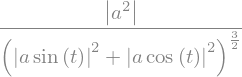

In [173]:
r = Matrix([a*cos(t), a*sin(t), 0])
simplify( r.diff(t).cross( r.diff((t,2)) ).norm() / r.diff(t).norm()**3 )

In [175]:
r = Matrix([2*t, 3*t, 0])
simplify( r.diff(t).cross( r.diff((t,2)) ).norm() / r.diff(t).norm()**3 )

## Ejercicios

Utilice Python/SymPy para resolver los siguientes ejercicios:

**1.** Resuelva las siguientes ecuaciones (para la variable $x$):
  * $ x + 3x = 10 $
  * $ 2x^2 - 10x + 5 = 0 $
  * $ \frac{a}{x} + bx - 8 = 0 $
  * $ \cos x + \sin x = 10 $
  * $ kx - 10 = x^2 $

**2**. Calcule las siguientes derivadas:
* $ \frac{d}{dx} \left( \cos x \right) $
* $ \frac{d}{dt} \left( at^2 - 2\tan t - \frac{10}{t} \right) $
* $ \frac{d}{dz} \left( z^5 - 10 e^{-z}  \right) $

**3.** Calcule las siguientes integrales indefinidas:
* $ \int \cos x \, dx $
* $ \int \left( x^3 - 8x \right)\, dx $
* $ \int \left( e^{-3x} \sin x \right) \, dx $
* $ \int \left( s^2 + ks - m \right) \, ds $

**4**. Calcule las siguientes integrales definidas:
* $ \int_{a}^{b} \sin x \, dx $
* $ \int_{-10}^{5} x^2 + 10x \, dx $
* $ \int_{0}^{2} 10e^{-z} \, dz  $

**5.** Resuelva la siguiente ecuación diferencial de primer orden:

$$ \frac{dS}{dr} = kS $$

**6.** Escriba una función que dados como entrada dos vectores, determine sí estos son 
paralelos (*Sugerencia: puedes utilizar el producto cruz*).

**7.** En estática, la fuerza resultante $\vec{F}_R$ de un sistema de fuerzas corresponde a la suma vectorial de los vectores fuerza:

$$
\vec{F}_R = \Sigma \vec{F} = \vec{F}_1 + \vec{F}_2 + \cdots + \vec{F}_n
$$

Desarrolle una función llamada `calcula_fuerza_resultante` que reciba como datos de entrada un conjunto de vectores fuerza y devuelva el vector de fuerza resultante.


**8.** En estática, el momento resultante de un sistema de fuerzas con respecto a un **punto** $O$ dado se puede determinar sumando los momentos que producen cada una de las fuerzas:

$$ 
\left( \vec{M}_R \right)_O = \Sigma \left( \vec{r} \times \vec{F} \right) = 
\vec{r}_1 \times \vec{F}_1 + \vec{r}_2 \times \vec{F}_2 + \cdots +  \vec{r}_n \times \vec{F}_n
$$

Donde $\vec{r}_i$ son vectores de posición y $\vec{F}_i$ los vectores de fuerza. Escriba un función llamada `calcula_momento_resultante` que reciba como datos de entrada un conjunto de 
vectores fuerza y un conjunto de vectores de posición. Se deberá devolver el momento total producido por las fuerzas con respecto al punto.